In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
from utils.cub_config import Config

d:\Programas\Anaconda\envs\ia_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda:0


In [3]:
model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
preprocess = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
test_images = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg"
]


Imagem: ../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg
Classe Predita: 26 (Prob: 0.1876)


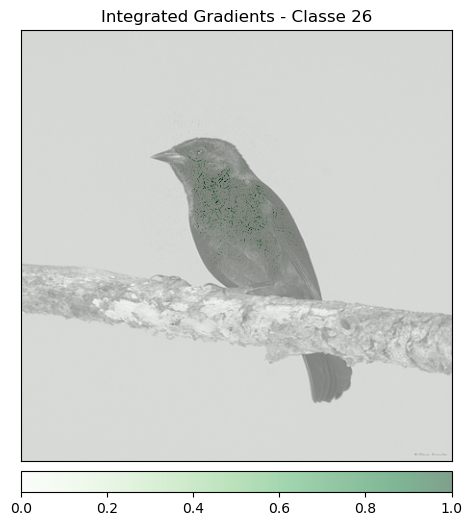

Explicação salva em: ../../out\ig_Shiny_Cowbird_0015_796858.jpg


In [16]:
ig = IntegratedGradients(model)

for img_path in test_images:

    image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    output = model(input_tensor)
    pred_prob = F.softmax(output, dim=1)
    pred_class_idx = torch.argmax(pred_prob, dim=1).item()
    pred_class_prob = pred_prob[0, pred_class_idx].item()

    print(f"\nImagem: {img_path}")
    print(f"Classe Predita: {pred_class_idx} (Prob: {pred_class_prob:.4f})")

    baseline = torch.zeros_like(input_tensor).to(device)

    attributions_ig = ig.attribute(input_tensor,
                                   baselines=baseline,
                                   target=pred_class_idx,
                                   n_steps=50,
                                   internal_batch_size=10,
                                   return_convergence_delta=False)
    

    attr_np = attributions_ig.squeeze().cpu().detach().numpy()
    attr_np = np.transpose(attr_np, (1, 2, 0))

    img_np = np.array(image.resize((448, 448))) / 255.0


    fig, _ = viz.visualize_image_attr(
        attr_np,
        img_np,
        method="blended_heat_map",
        sign="positive",  
        show_colorbar=True,
        title=f"Integrated Gradients - Classe {pred_class_idx}",
        use_pyplot=True 
    )
    
    # Salvar a figura
    out_filename = f"ig_{os.path.basename(img_path)}"
    save_path = os.path.join(Config.OUTPUT_DIR, out_filename)
    fig.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"Explicação salva em: {save_path}")
    
    plt.close()
